Deep Learning Models: A collection of various deep learning architectures, models, & their implementations (`PyTorch` or `TensorFlow`) in Jupyter Notebooks.
* Author: _Chizoba Obasi_
* Github Repo: https://github.com/chizkidd/deep-learning-models

In [1]:
!pip install watermark

In [2]:
!pip install torchinfo datasets

In [3]:
%load_ext watermark
# %reload_ext watermark
%watermark -a 'Chizoba Obasi' -v -p torch

Author: Chizoba Obasi

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

torch: 2.8.0+cu126



# Single-Layer Recurrent Neural Network (RNN) Classifier on IMDB Reviews

The network in this notebook is an implementation of a simple RNN **[1]** on IMDB reviews **[5]**.

**Network Architecture:**

The Elman RNN (or Simple RNN) replaced the "static" assumption of standard Feed-forward networks by introducing a **Hidden State ($h_t$)** **[4]**. This creates a feedback loop where the network's output at one time step becomes an input for the next, allowing the model to process sequences of variable length.


![RNN architecture](https://d2l.ai/_images/rnn.svg)

[Source](https://d2l.ai/chapter_recurrent-neural-networks/rnn.html)


---

### **Key Concepts of the `RNN` Architecture:**

1. **Hidden State Recurrence ($h_t$):** Unlike `NiN` or `ResNet` which only pass information forward, the RNN maintains a "hidden state" that acts as the network's internal memory. At each time step $t$, the current input $x_t$ is combined with the previous hidden state $h_{t-1}$ to produce a new $h_t$. This allows the model to capture temporal dependencies in text.<br><br>
2. **Shared Weights Across Time:** In a CNN, weights are shared across spatial locations (pixels). In an RNN, the same weights ($W_{ih}$ and $W_{hh}$) are reused at **every single time step**. This drastically reduces the parameter count compared to a massive Flatten layer and allows the model to generalize across different sentence lengths.<br><br>
3. **Many-to-One Mapping:** For classification tasks like IMDB (Sentiment) or AG News (Topic), we process the entire sequence but only use the **final hidden state** for the prediction. This final state acts as a "neural summary" of the entire sentence, similar to how **Global Average Pooling** summarizes a feature map.

---
### **Improvements of `RNN` over Deep `CNN`:**

1. **Temporal Dependency Modeling:** Standard CNNs (like `VGG` or `ResNet`) assume that inputs are independent of each other. While a CNN is excellent at extracting spatial features (like a nose in a face), it cannot inherently understand that "not" at the beginning of a sentence changes the meaning of "good" at the end. `RNNs` introduce **Recurrence**, allowing the network to build a "contextual summary" as it reads through a sequence.<br><br>
2. **Variable-Length Processing:** Traditional deep CNNs require a fixed-size input (e.g., $224\times224$ pixels). If an image is larger or smaller, it must be resized. `RNNs` are architecturally flexible; because the same weights are applied at every step, the model can process a 5-word tweet or a 500-word review using the exact same number of parameters.<br><br>
3. **Parameter Efficiency for Sequences:** To capture long-range dependencies in a CNN, one would need a massive receptive field (very deep layers or huge kernels). An `RNN` achieves this "depth" through time. By reusing the same $W_{hh}$ (Hidden-to-Hidden) matrix, the model achieves a form of "infinite depth" in the temporal dimension without the explosive memory cost of the 4096-unit fully connected layers found in `AlexNet` or `VGG`.

---

### **Quick Comparison Table: CNN vs. RNN Architecture**

| Feature | CNN (NiN / ResNet / VGG) | Recurrent Neural Network (RNN) |
| :--- | :--- | :--- |
| **Primary Data Type** | Spatial (Images, Grids, Fixed-size) | **Sequential (Text, Audio, Time-series)** |
| **Input Relationship** | Assumes inputs are independent | **Assumes inputs are temporally dependent** |
| **Information Flow** | Feed-forward (Layer $L \to L+1$) | **Recurrent (Step $T-1 \to T$)** |
| **Weight Sharing** | Across **Space** (Kernel sliding) | Across **Time** (Step-wise recurrence) |
| **Memory Mechanism** | No internal memory (Static) | **Hidden State ($h_t$)** (Internal memory) |
| **Input Constraints** | Requires fixed-size (Resizing/Padding) | **Handles variable-length sequences** |
| **Pattern Recognition** | Extracts local features (Edges, Shapes) | Extracts **Contextual context** (Grammar, Logic) |
| **Downsampling** | Max Pooling / Global Average Pooling | **Final Hidden State** (Sequence summary) |

<br><br>

**REFERENCES:**
1. Elman, Jeffrey L. ["Finding Structure in Time."](https://onlinelibrary.wiley.com/doi/abs/10.1207/s15516709cog1402_1) Cognitive Science, 1990.
2. PyTorch. ["Recurrent Layers: nn.RNN."](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html) *PyTorch Documentation*, 2026.
3. Zhang, Aston, et al. ["Recurrent Neural Networks (Chapter 9.1)."](https://d2l.ai/chapter_recurrent-neural-networks/rnn.html) _Dive into Deep Learning_. Cambridge University Press, 2023.
4. Raschka, Sebastian. ["L15: Introduction to recurrent neural networks."](https://sebastianraschka.com/blog/2021/dl-course.html#l15-introduction-to-recurrent-neural-networks) *Introduction to Deep Learning*, 2021. [[slides](https://sebastianraschka.com/pdf/lecture-notes/stat453ss21/L15_intro-rnn__slides.pdf)]
5. Maas, Andrew L., et al. ["Learning Word Vectors for Sentiment Analysis."](https://ai.stanford.edu/~amaas/papers/wv_sent_analysis.pdf) *Proceedings of the 49th Annual Meeting of the Association for Computational Linguistics: Human Language Technologies*, 2011.
6. Google. (2026). ["Gemini 3 Flash"](https://gemini.google.com/) [Large language model]. Google AI.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from datasets import load_dataset, DatasetDict
from collections import Counter


# from torch.cuda.amp import GradScaler, autocast
from torch.amp import GradScaler, autocast
from torchinfo import summary

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

import pandas as pd
import numpy as np
import math
import time
import os
import re
import random

if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [5]:
def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

---
# 0. Model Hyperparameters
---

In [6]:
##########################
### SETTINGS
##########################

# Hyperparameters
RANDOM_SEED = 123
BATCH_SIZE = 128 
LEARNING_RATE = 0.001
NUM_EPOCHS = 15
NUM_CLASSES = 2

VOCABULARY_SIZE = 20000

EMBEDDING_DIM = 128
HIDDEN_DIM = 256
OUTPUT_DIM = 1

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


---
# 1. Data Preparation & Loading

---

In [7]:
# 1. Load Dataset (IMDB)
raw_datasets = load_dataset("imdb")


# 2. Split 10% of 'train' to create a 'validation' set (seed for reproducibility)
train_val_split = raw_datasets["train"].train_test_split(test_size=0.1, seed=RANDOM_SEED)

ds_splits = DatasetDict({
    'train': train_val_split['train'],
    'validation': train_val_split['test'], # The 10% we just carved out
    'test': raw_datasets['test']
})

print(ds_splits)

# 2. Build Vocabulary (From Scratch Logic)
tokenizer = lambda text: re.findall(r'\w+', text.lower())
word_counts = Counter()

# Important: We only iterate over ds_splits['train']
for text in ds_splits['train']['text']:
    word_counts.update(tokenizer(text))

# Filter rare words and create mapping: : <PAD>=0, <UNK>=1, then top 20k words
vocab = {word: i + 2 for i, (word, count) in enumerate(word_counts.most_common(VOCABULARY_SIZE))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

print(f"Vocab size: {len(vocab)}")

# 3. Custom Dataset Class 
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, dataset_split, vocab, max_len=256):
        self.data = dataset_split
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        tokens = tokenizer(item['text'])
        
        # Numericalize
        ids = [self.vocab.get(t, 1) for t in tokens]
        
        # Manual Padding/Truncating
        curr_len = len(ids)
        if curr_len < self.max_len:
            ids += [0] * (self.max_len - curr_len)
        else:
            ids = ids[:self.max_len]
            curr_len = self.max_len
            
        # Label handling (float for binary, long for multi-class)
        # For AG News, we'd use dtype=torch.long
        label = torch.tensor(item['label'], dtype=torch.float)
            
        return torch.tensor(ids), label, torch.tensor(curr_len)

# 4. DataLoaders
# Create the robust Dataset objects
train_ds = TextDataset(ds_splits['train'], vocab)
val_ds   = TextDataset(ds_splits['validation'], vocab)
test_ds  = TextDataset(ds_splits['test'], vocab)

# Create the DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 22500
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2500
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
})
Vocab size: 20002


---

**How do we figure out a good `max_len`? see code below**

---

```python
def get_robust_maxlen(dataset, tokenizer, p=95, absolute_max=512):
    # 1. Get the statistical length
    lengths = [len(tokenizer(ex[0])) for ex in dataset]
    p_length = np.percentile(lengths, p)
    
    # 2. Find the next power of 2
    # math.log2 gives the exponent, ceil rounds up, 2** raises it back
    # We use max(16, ...) to ensure we don't get a tiny length like 4 or 8
    robust_len = 2 ** math.ceil(math.log2(max(16, p_length)))
    
    # 3. Cap at absolute_max
    final_len = min(robust_len, absolute_max)
    
    print(f"{p}th Percentile: {p_length:.2f}")
    print(f"Nearest Power of 2: {robust_len}")
    print(f"Final Robust MAX_LEN: {final_len}")
    
    return final_len

# Usage
__MAX_LEN = get_robust_maxlen(train_ds, tokenizer, p=95)
```


---
# 2. Model Creation

---

In [8]:
class RNNFromScratch(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.w_ih = nn.Linear(embed_dim, hidden_size)
        self.w_hh = nn.Linear(hidden_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x, lengths):
        # Transform indices to vectors: [Batch, Seq_Len, Embed_Dim]
        embedded = self.embedding(x)
        
        # embedded shape: [Batch, Seq_Len, embed_Size]
        batch_size, seq_len, _ = embedded.size()
        
        # Initialize hidden state with zeros
        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        
        # Manual loop over time steps (The "Recurrent" part)
        all_h = []
        for t in range(seq_len):
            x_t = embedded[:, t, :] # Get current time step
            h_t = torch.tanh(self.w_ih(x_t) + self.w_hh(h_t))
            all_h.append(h_t)

        all_h = torch.stack(all_h)
        last_indices = (lengths - 1).long().to(x.device)
        h_final = all_h[last_indices, torch.arange(batch_size)]
            
        # Only take the final hidden state for classification
        out = self.fc(h_final)
        return out

In [9]:
VOCAB_SIZE = len(vocab)
INPUT_SIZE = EMBEDDING_DIM

In [10]:
# --- Configuration Switch ---
DATASET_NAME = "IMDB" # or "AG_NEWS"

if DATASET_NAME == "IMDB":
    IS_BINARY = True
    NUM_CLASSES = 1
    # criterion = nn.BCEWithLogitsLoss()
else:
    IS_BINARY = False
    NUM_CLASSES = 4 # AG News has 4 classes
    # criterion = nn.CrossEntropyLoss()

In [11]:
set_all_seeds(RANDOM_SEED)
model = RNNFromScratch(
    vocab_size=VOCAB_SIZE, 
    embed_dim=EMBEDDING_DIM, 
    hidden_size=HIDDEN_DIM, 
    output_size=NUM_CLASSES
).to(DEVICE)

# Note: RNNFromScratch needs two inputs: the indices and the lengths
# We simulate a batch of 64 with a sequence length of 256
# Wrap the inputs in a tuple so torchinfo knows exactly how to unpack them into forward(x, lengths)
summary(model, 
        input_data=(
            torch.zeros((BATCH_SIZE, INPUT_SIZE), dtype=torch.long).to(DEVICE),
            torch.ones((BATCH_SIZE,), dtype=torch.long).to(DEVICE) * INPUT_SIZE
        ),
        col_names=["input_size", "output_size", "num_params", "mult_adds"],
        device=DEVICE)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
RNNFromScratch                           [128, 128]                [128, 1]                  --                        --
├─Embedding: 1-1                         [128, 128]                [128, 128, 128]           2,560,256                 327,712,768
├─Linear: 1-2                            [128, 128]                [128, 256]                33,024                    4,227,072
├─Linear: 1-3                            [128, 256]                [128, 256]                65,792                    8,421,376
├─Linear: 1-4                            [128, 128]                [128, 256]                (recursive)               4,227,072
├─Linear: 1-5                            [128, 256]                [128, 256]                (recursive)               8,421,376
├─Linear: 1-6                            [128, 128]                [128, 256]                (recursiv

---
# 3. Model Training, Testing & Evaluation

---

In [12]:
def calculate_accuracy(loader, model, device, is_binary=True):
    model.eval()
    correct, total = 0, 0
    
    with torch.no_grad():
        for inputs, labels, lengths in loader:
            inputs, labels, lengths = inputs.to(device), labels.to(device), lengths.to(device)
            logits = model(inputs, lengths)
            
            if is_binary:
                predicted = (torch.sigmoid(logits.view(-1)) > 0.5).long()
            else:
                _, predicted = torch.max(logits.data, 1)
                
            total += labels.size(0)
            correct += (predicted == labels.long()).sum().item()
            
    return 100 * correct / total

In [13]:
# Configuration
IS_BINARY, NUM_CLASSES 

(True, 1)

In [14]:
criterion = nn.BCEWithLogitsLoss() if IS_BINARY else nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Robust Scheduler: Cosine Annealing 
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [15]:
start_time = time.time()
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lrs': []}

print(f"Starting training on {DEVICE}...")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    
    # 1. Training Phase
    for i, (inputs, labels, lengths) in enumerate(train_loader):
        inputs, labels, lengths = inputs.to(DEVICE), labels.to(DEVICE), lengths.to(DEVICE)

        optimizer.zero_grad()
        
        # Forward pass (passing lengths for masking logic)
        logits = model(inputs, lengths)
        
        if IS_BINARY:
            loss = criterion(logits.squeeze(), labels)
        else:
            loss = criterion(logits, labels.long())
            
        loss.backward()
        
        # --- ROBUST RNN FIX: Gradient Clipping ---
        # Prevents gradients from "exploding" during the backprop through time (BPTT)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    # 2. Metrics Calculation
    # Note: Using the updated calculate_accuracy that handles (inputs, lengths)
    train_loss = running_loss / len(train_ds)
    train_acc = calculate_accuracy(train_loader, model, DEVICE, is_binary=IS_BINARY)

    # 3. Validation Phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels, lengths in val_loader:
            inputs, labels, lengths = inputs.to(DEVICE), labels.to(DEVICE), lengths.to(DEVICE)
            
            logits = model(inputs, lengths)
            
            if IS_BINARY:
                loss = criterion(logits.squeeze(), labels)
            else:
                loss = criterion(logits, labels.long())
                
            val_loss += loss.item() * inputs.size(0)

    val_loss /= len(val_ds)
    val_acc = calculate_accuracy(val_loader, model, DEVICE, is_binary=IS_BINARY)

    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    # 4. Logging
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lrs'].append(current_lr)

    print(f'Epoch {epoch + 1}/{NUM_EPOCHS} | '
          f'Loss (train/val): {train_loss:.4f} / {val_loss:.4f} | '
          f'Acc (train/val): {train_acc:.2f}% / {val_acc:.2f}% | '
          f'LR: {current_lr:.6f}')

print('\nTotal Training Time: %.2f min' % ((time.time() - start_time)/60))

Starting training on cuda...
Epoch 1/15 | Loss (train/val): 0.6802 / 0.6798 | Acc (train/val): 59.79% / 59.08% | LR: 0.000989
Epoch 2/15 | Loss (train/val): 0.6221 / 0.6044 | Acc (train/val): 72.03% / 68.52% | LR: 0.000957
Epoch 3/15 | Loss (train/val): 0.5559 / 0.6023 | Acc (train/val): 75.79% / 71.20% | LR: 0.000905
Epoch 4/15 | Loss (train/val): 0.5006 / 0.5848 | Acc (train/val): 78.97% / 69.80% | LR: 0.000835
Epoch 5/15 | Loss (train/val): 0.4489 / 0.5454 | Acc (train/val): 82.12% / 73.24% | LR: 0.000750
Epoch 6/15 | Loss (train/val): 0.4566 / 0.5537 | Acc (train/val): 81.38% / 74.72% | LR: 0.000655
Epoch 7/15 | Loss (train/val): 0.4403 / 0.5285 | Acc (train/val): 83.77% / 75.08% | LR: 0.000552
Epoch 8/15 | Loss (train/val): 0.3958 / 0.4959 | Acc (train/val): 85.68% / 78.96% | LR: 0.000448
Epoch 9/15 | Loss (train/val): 0.3692 / 0.5258 | Acc (train/val): 84.58% / 75.12% | LR: 0.000345
Epoch 10/15 | Loss (train/val): 0.3260 / 0.4848 | Acc (train/val): 88.84% / 80.04% | LR: 0.000250


In [16]:
# --- Final Evaluation ---
test_accuracy = calculate_accuracy(test_loader, model, DEVICE, is_binary=IS_BINARY)
print(f'\nFinal Test Accuracy: {test_accuracy:.2f}%')


Final Test Accuracy: 80.40%


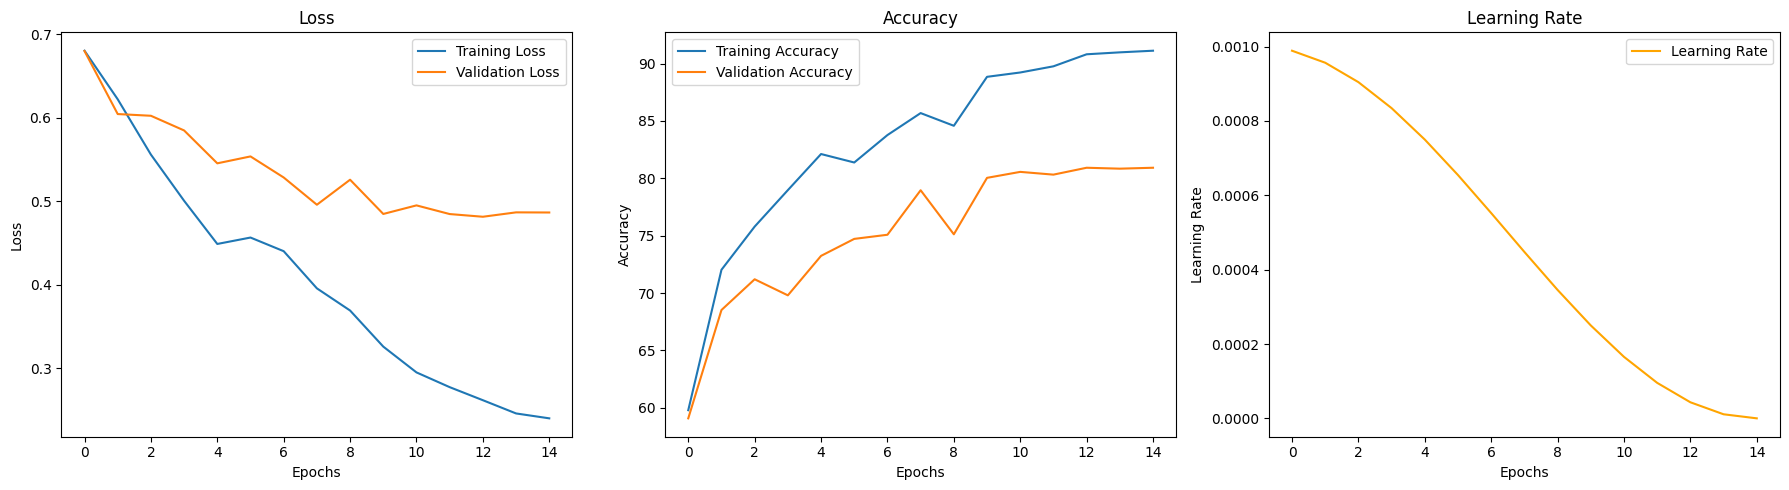

In [17]:
def plot_history(history):
    """
    Plots the training and validation loss, accuracy, and learning rate
    from a PyTorch history dictionary.

    Args:
        history (dict): Dictionary containing training metrics.
                        Expected keys: 'train_loss', 'val_loss', 'train_acc', 'val_acc', 'lrs'.
    """
    epochs = range(len(history['train_loss']))

    plt.figure(figsize=(18, 5))

    # Plot 1: Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], label='Training Loss')
    plt.plot(epochs, history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    # plt.grid(True)

    # Plot 2: Accuracy
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['train_acc'], label='Training Accuracy')
    plt.plot(epochs, history['val_acc'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    # plt.grid(True)

    # Plot 3: Learning Rate
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['lrs'], label='Learning Rate', color='orange')
    plt.title('Learning Rate')
    plt.xlabel('Epochs')
    plt.ylabel('Learning Rate')
    plt.legend()
    # plt.grid(True)

    plt.tight_layout()
    plt.show()
    # plt.savefig()

plot_history(history)

---
## 4. Model Inference and Sentiment Prediction

---

In [20]:
# Adapted the below code from:
# https://github.com/bentrevett/pytorch-sentiment-analysis/blob/experimental/2%20-%20Upgraded%20Sentiment%20Analysis.ipynb
def predict_sentiment(model, sentence):
    model.eval()
    
    # Tokenize and convert to indices
    tokens = tokenizer(sentence)
    indexed = [vocab.get(t, 1) for t in tokens]
    
    # Create tensors and move to device
    tensor = torch.LongTensor(indexed).unsqueeze(0).to(DEVICE) # [1, seq_len]
    length = torch.LongTensor([len(indexed)]).to(DEVICE)       # [1]
    
    with torch.no_grad():
        # Pass both tensor AND length to your RNNFromScratch
        logits = model(tensor, length)
        
        # Apply sigmoid for the 0.0-1.0 probability
        prob = torch.sigmoid(logits.view(-1)).item()
        
    return prob

# Test the inference
sentence = "This film was an absolute masterpiece of modern cinema."
prob = predict_sentiment(model, sentence)
print(f'Sentence: "{sentence}"')
print(f'Probability positive: {prob:.4f}')
print(f'Predicted Sentiment: {"Positive" if prob > 0.5 else "Negative"}')

Sentence: "This film was an absolute masterpiece of modern cinema."
Probability positive: 0.8450
Predicted Sentiment: Positive


In [21]:
predict_sentiment(model, "This film is terrible")

0.11094806343317032

In [22]:
predict_sentiment(model, "This film is quite interesting")

0.2711936831474304

In [23]:
imdb_tests = [
    "I wanted to like this movie, but the acting was wooden and the plot was a mess.", # Negative
    "An absolute triumph of cinema that I would recommend to everyone I know.",       # Positive
    "Not the worst thing I've ever seen, but definitely not the best either.",       # Neutral/Leaning Neg
    "The special effects were stunning, though the story felt a bit rushed.",         # Mixed
    "I fell asleep halfway through; avoid this waste of time at all costs."          # Highly Negative
]

print(f"{'Review':<60} | {'Prob':<6} | {'Sentiment'}")
print("-" * 80)

for text in imdb_tests:
    prob = predict_sentiment(model, text)
    sentiment = "Positive" if prob > 0.5 else "Negative"
    print(f"{text[:58]:<60} | {prob:.3f} | {sentiment}")

Review                                                       | Prob   | Sentiment
--------------------------------------------------------------------------------
I wanted to like this movie, but the acting was wooden and   | 0.009 | Negative
An absolute triumph of cinema that I would recommend to ev   | 0.983 | Positive
Not the worst thing I've ever seen, but definitely not the   | 0.024 | Negative
The special effects were stunning, though the story felt a   | 0.994 | Positive
I fell asleep halfway through; avoid this waste of time at   | 0.005 | Negative


In [24]:
%watermark -iv

datasets   : 4.4.1
matplotlib : 3.10.0
numpy      : 2.0.2
pandas     : 2.2.2
re         : 2.2.1
sklearn    : 1.6.1
torch      : 2.8.0+cu126
torchinfo  : 1.8.0
torchvision: 0.23.0+cu126

